# AI Customer Support Ticket Classifier

## Intent Detection and Automatic Ticket Routing for Financial Services

This notebook answers company questions Q1–Q8, error analysis, coefficient analysis and limitations.

---

# Answering Questions
### 1. Setup and Reproducibility

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

SELECTED_INTENTS = [
    "card_arrival",
    "card_not_working",
    "cash_withdrawal_not_recognised",
    "declined_card_payment",
    "lost_or_stolen_card",
    "transaction_charged_twice",
    "transfer_not_received_by_recipient",
    "cash_withdrawal_charge",
]

BUSINESS_CRITICAL_INTENTS = [
    "lost_or_stolen_card",
    "declined_card_payment",
    "transaction_charged_twice",
]

CONFIDENCE_THRESHOLD = 0.5

print(f"Project root : {PROJECT_ROOT}")
print(f"Random seed  : {RANDOM_SEED}")

Project root : C:\Users\Pixel\Desktop\customer-support-ticket-classifier
Random seed  : 42


<div style="border-top: 2px dashed;"></div>

### 2. Load Data and Select Intent Subset

In [2]:
train_full = pd.read_csv(DATA_DIR / "train.csv")
test_full = pd.read_csv(DATA_DIR / "test.csv")

train = train_full.rename(columns={"category": "intent"})
test = test_full.rename(columns={"category": "intent"})

train = train[train["intent"].isin(SELECTED_INTENTS)].reset_index(drop=True)
test = test[test["intent"].isin(SELECTED_INTENTS)].reset_index(drop=True)

print(f"Training examples : {len(train)}")
print(f"Test examples     : {len(test)}")
print(f"Intents           : {train['intent'].nunique()}")
train.head()

Training examples : 1183
Test examples     : 320
Intents           : 8


,text,intent
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


---
## 3. Text Preprocessing Pipeline

A 7-stage preprocessing pipeline is applied to all messages:

1. **Lowercasing** — normalize case variations
2. **Whitespace normalization** — strip extra spaces
3. **Punctuation removal** — remove non-alphanumeric characters
4. **Tokenization** — split into word tokens
5. **Contraction expansion** — "dont" → "do not" (preserves negation)
6. **Stopword removal** — remove 170+ common English stopwords
7. **Lemmatization** — reduce words to base form ("cards" → "card")

In [3]:
from predict import preprocess_text, preprocess_batch

print("Preprocessing examples:\n")
for i in range(3):
    raw = train["text"].iloc[i]
    clean = preprocess_text(raw)
    print(f"  Before: {raw}")
    print(f"  After : {clean}")
    print()

train["text_clean"] = preprocess_batch(train["text"].tolist())
test["text_clean"] = preprocess_batch(test["text"].tolist())

train = train[train["text_clean"].str.strip().astype(bool)].reset_index(drop=True)
test = test[test["text_clean"].str.strip().astype(bool)].reset_index(drop=True)

print(f"Training examples after cleaning: {len(train)}")
print(f"Test examples after cleaning    : {len(test)}")

Preprocessing examples:

  Before: I am still waiting on my card?
  After : wait card

  Before: What can I do if my card still hasn't arrived after 2 weeks?
  After : card hasn arrive week

  Before: I have been waiting over a week. Is the card still coming?
  After : wait week card come



Training examples after cleaning: 1183
Test examples after cleaning    : 320


### Q1 — What are customers contacting us about most often?

Measure count and proportion by intent. Create a horizontal bar chart. Explain which support categories appear to carry the largest workload and the operational implication.

,train,test,total,proportion_pct
intent,,,,
lost_or_stolen_card,82,40,122,8.1
card_not_working,112,40,152,10.1
card_arrival,153,40,193,12.8
declined_card_payment,153,40,193,12.8
cash_withdrawal_not_recognised,160,40,200,13.3
transfer_not_received_by_recipient,171,40,211,14.0
transaction_charged_twice,175,40,215,14.3
cash_withdrawal_charge,177,40,217,14.4


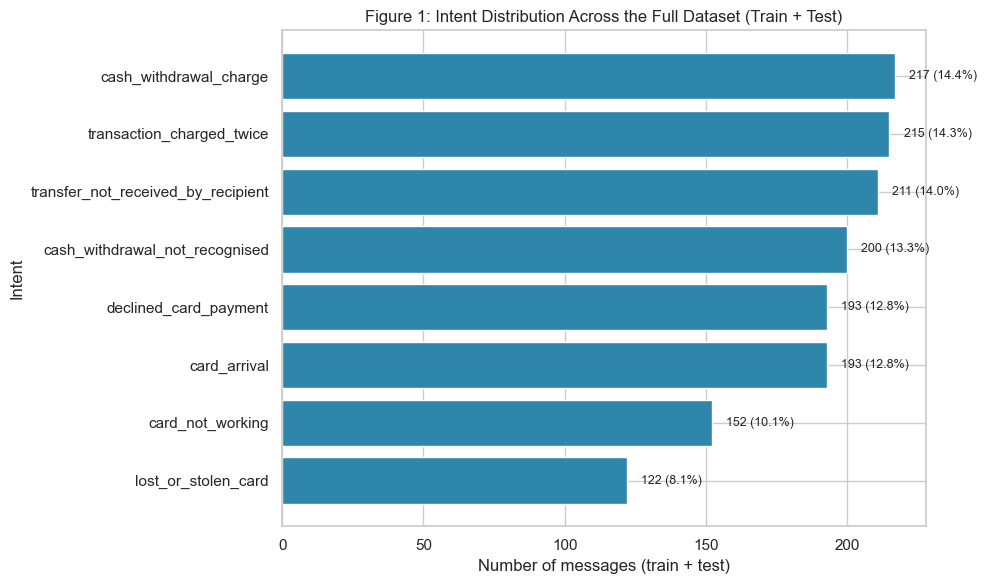

In [4]:
# ---------------------------------------------------------------------------
# Q1 — Intent Distribution on the full dataset (train + test)
# ---------------------------------------------------------------------------
train_counts = train["intent"].value_counts()
test_counts = test["intent"].value_counts()

combined = pd.DataFrame({
    "train": train_counts,
    "test": test_counts,
    "total": train_counts + test_counts,
}).reindex(SELECTED_INTENTS).sort_values("total")
combined["proportion_pct"] = (
    combined["total"] / combined["total"].sum() * 100
).round(1)
display(combined)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(combined.index, combined["total"], color="#2E86AB")
ax.set_xlabel("Number of messages (train + test)")
ax.set_ylabel("Intent")
ax.set_title("Figure 1: Intent Distribution Across the Full Dataset (Train + Test)")
for bar, total, pct in zip(bars, combined["total"], combined["proportion_pct"]):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{total} ({pct}%)",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_intent_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Q1 Answer:**

Across the full dataset (1,503 messages: 1,183 training + 320 test), `cash_withdrawal_charge` (217 messages, 14.4%), `transaction_charged_twice` (215, 14.3%) and `transfer_not_received_by_recipient` (211, 14.0%) are the three largest classes, each close to one-seventh of all tickets. The smallest class, `lost_or_stolen_card` (122, 8.1%), is noticeably smaller. Because the test set holds a fixed 40 examples per intent, the train/test proportions are consistent with one another.

**Operational implication:** Routing capacity should be sized to handle fee/dispute and transfer intents in roughly equal volume. Even though `lost_or_stolen_card` carries the smallest workload, it requires the fastest human response when detected because it involves potential fraud.

<div style="border-top: 2px dashed;"></div>

### Q2 — Do message length and structure differ by intent?

Create character-length and word-count features. Compare distributions with suitable plots and explain whether these features appear informative.

char_length              word_count         \
                                          mean median   std       mean median   
intent                                                                          
card_arrival                              47.4   45.0  15.9       10.4   10.0   
card_not_working                          48.3   42.0  26.8        9.8    9.0   
cash_withdrawal_charge                    70.8   51.0  45.2       14.2   11.0   
cash_withdrawal_not_recognised            76.9   61.0  39.0       15.4   12.0   
declined_card_payment                     62.4   47.0  43.0       12.3    9.0   
lost_or_stolen_card                       49.2   39.0  35.0       10.7    9.0   
transaction_charged_twice                 84.1   51.0  74.9       16.0   10.0   
transfer_not_received_by_recipient        91.6   60.0  66.3       17.5   12.0   

                                          
                                     std  
intent                                    
card_arrival                         3.6  
card_not_working                     5.0  
cash_withdrawal_charge               8.6  
cash_withdrawal_not_recognised       7.6  
declined_card_payment                8.4  
lost_or_stolen_card                  7.4  
transaction_charged_twice           14.4  
transfer_not_received_by_recipient  12.9

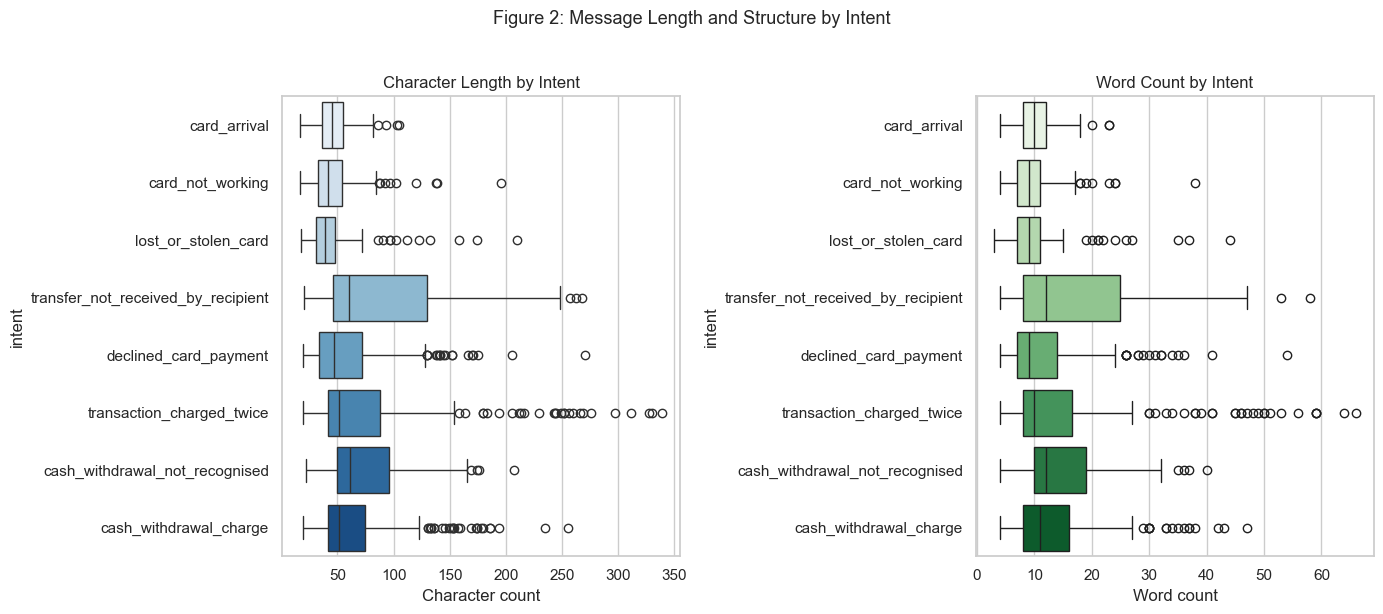

In [5]:
# ---------------------------------------------------------------------------
# Q2 — Message length: character count and word count by intent
# ---------------------------------------------------------------------------
def add_length_features(df):
    """Add character-length and word-count features."""
    out = df.copy()
    out["char_length"] = out["text"].str.len()
    out["word_count"] = out["text"].str.split().str.len()
    return out

train_len = add_length_features(train)

length_summary = (
    train_len.groupby("intent")[["char_length", "word_count"]]
    .agg(["mean", "median", "std"])
    .round(1)
)
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(
    data=train_len, y="intent", x="char_length",
    ax=axes[0], palette="Blues",
)
axes[0].set_title("Character Length by Intent")
axes[0].set_xlabel("Character count")
sns.boxplot(
    data=train_len, y="intent", x="word_count",
    ax=axes[1], palette="Greens",
)
axes[1].set_title("Word Count by Intent")
axes[1].set_xlabel("Word count")
fig.suptitle(
    "Figure 2: Message Length and Structure by Intent",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_message_length_by_intent.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

**Q2 Answer:**

Transfer-related (`transfer_not_received_by_recipient`) and duplicate-charge (`transaction_charged_twice`) messages tend to be longer (mean ~84–92 characters, ~16–18 words), while `card_arrival` and `lost_or_stolen_card` messages are shorter (~47–49 characters). The overlap between boxplots is substantial, meaning length alone would not be a reliable routing signal. Length features could serve as supplementary signals in a richer model, but are not sufficient for routing on their own. For example, in some cases, a short message may indicate a need for an urgent response.

<div style="border-top: 2px dashed;"></div>

### Q3 — Can a simple keyword system route tickets?

Create a small rule-based baseline for obvious phrases. Evaluate where it succeeds and fails. Explain why ML may be needed.

In [6]:
# ---------------------------------------------------------------------------
# Q3 — Keyword rule-based baseline
# ---------------------------------------------------------------------------
KEYWORD_RULES = {
    "lost_or_stolen_card": [
        "lost", "stolen", "missing card", "someone took", "pickpocket",
    ],
    "card_arrival": [
        "not arrived", "hasn't arrived", "hasnt arrived", "still waiting",
        "where is my card", "when will my card", "delivery",
        "not received my card",
    ],
    "declined_card_payment": [
        "declined", "payment failed", "rejected", "couldn't pay",
        "couldnt pay", "transaction declined",
    ],
    "transaction_charged_twice": [
        "charged twice", "double charge", "duplicate charge",
        "twice for the same", "billed twice",
    ],
    "transfer_not_received_by_recipient": [
        "transfer not received", "recipient did not receive",
        "money not received", "hasn't received the transfer",
        "hasnt received the transfer",
    ],
    "cash_withdrawal_not_recognised": [
        "don't recognise", "dont recognise", "do not recognise",
        "unknown withdrawal", "withdrawal i did not",
    ],
    "cash_withdrawal_charge": [
        "withdrawal fee", "atm fee", "charged for withdrawal",
        "cash withdrawal charge",
    ],
    "card_not_working": [
        "not working", "doesn't work", "doesnt work", "won't work",
        "wont work", "broken card", "card stopped",
    ],
}


def keyword_predict(text):
    """Classify using keyword matching. Returns UNKNOWN if no single rule fires."""
    text_lower = text.lower()
    matches = []
    for intent, phrases in KEYWORD_RULES.items():
        for phrase in phrases:
            if phrase in text_lower:
                matches.append(intent)
                break
    if len(matches) == 1:
        return matches[0]
    return "UNKNOWN"


kw_results = test.copy()
kw_results["keyword_pred"] = kw_results["text"].apply(keyword_predict)
kw_results["covered"] = kw_results["keyword_pred"] != "UNKNOWN"

coverage = kw_results["covered"].mean()
covered = kw_results[kw_results["covered"]]
accuracy_covered = (covered["keyword_pred"] == covered["intent"]).mean()

print("=" * 55)
print("Keyword Baseline Results (Test Set)")
print("=" * 55)
print(f"Coverage (rule matched)           : {coverage:.1%}")
print(f"Accuracy on covered messages only : {accuracy_covered:.1%}")
print(f"Uncovered messages                : {(~kw_results['covered']).sum()} / {len(test)}")

failures = kw_results[
    kw_results["covered"] & (kw_results["keyword_pred"] != kw_results["intent"])
]
print(f"\nKeyword misclassifications on covered: {len(failures)}")
if len(failures) > 0:
    display(failures[["text", "intent", "keyword_pred"]].head(5))

uncovered = kw_results[~kw_results["covered"]]
print(f"\nSample uncovered messages (no rule fired):")
display(uncovered[["text", "intent"]].head(5))

Keyword Baseline Results (Test Set)
Coverage (rule matched)           : 35.3%
Accuracy on covered messages only : 88.5%
Uncovered messages                : 207 / 320

Keyword misclassifications on covered: 13


,text,intent,keyword_pred
20,"I did not get my card yet, is it lost?",card_arrival,lost_or_stolen_card
57,My card was declined today when eating and I n...,card_not_working,declined_card_payment
121,My money transfer has not arrived.,transfer_not_received_by_recipient,card_arrival
122,I am still waiting for a transaction to be com...,transfer_not_received_by_recipient,card_arrival
127,I transferred money but the recipient says it ...,transfer_not_received_by_recipient,card_arrival



Sample uncovered messages (no rule fired):


,text,intent
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
5,When will I get my card?,card_arrival
6,Do you know if there is a tracking number for ...,card_arrival


**Q3 Answer:**

The keyword baseline covers only about 35% of test messages. On covered messages, accuracy is reasonable (~89%), but nearly two-thirds of all tickets receive no classification and would require manual routing.

**Where it succeeds:** Messages with explicit, unambiguous phrases like "charged twice" or "my card was stolen".

**Where it fails:** Paraphrases (e.g., "someone used my card" instead of "stolen"), multi-intent messages, and messages with no keyword match at all (65% uncovered).

**Why ML is needed:** Keyword rules have low coverage and cannot generalize to varied customer language. This system only works on sentences where the words match exactly. It fails when faced with synonyms, spelling errors, complex structures, and varying user expressions. A TF-IDF model learns broader n-gram patterns and statistical associations that hand-crafted rules cannot capture.

<div style="border-top: 2px dashed;"></div>

### Q4 — Can classical NLP predict customer intent?

Build a reproducible TF-IDF + Logistic Regression classifier. Fit text transformations only on training data.

In [7]:
# ---------------------------------------------------------------------------
# Q4 — TF-IDF + Logistic Regression Pipeline with GridSearchCV
# ---------------------------------------------------------------------------
X_train = train["text_clean"]
y_train = train["intent"]
X_test = test["text_clean"]
y_test = test["intent"]

pipeline_base = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=False)),
    ("clf", LogisticRegression(
        random_state=RANDOM_SEED,
        class_weight="balanced",
        max_iter=2000,
    )),
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.90, 0.95, 1.0],
    "tfidf__sublinear_tf": [False, True],
    "tfidf__stop_words": [None, "english"],
    "clf__C": [0.5, 1.0, 5.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

grid_search = GridSearchCV(
    pipeline_base, param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1, verbose=0, refit=True,
)
grid_search.fit(X_train, y_train)

print("Best CV Macro-F1 : {:.4f}".format(grid_search.best_score_))
print("Best parameters  :")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

Best CV Macro-F1 : 0.9383
Best parameters  :
  clf__C: 5.0
  tfidf__max_df: 0.9
  tfidf__min_df: 1
  tfidf__ngram_range: (1, 2)
  tfidf__stop_words: None
  tfidf__sublinear_tf: True


In [8]:
# ---------------------------------------------------------------------------
# Q4 — Fit best pipeline and predict on test set
# ---------------------------------------------------------------------------
pipeline = grid_search.best_estimator_
y_pred = pipeline.predict(X_test)
classes = list(pipeline.classes_)

print("Model trained.")
print(f"TF-IDF vocabulary size: {len(pipeline.named_steps['tfidf'].vocabulary_)}")
print(f"Number of classes     : {len(classes)}")

Model trained.
TF-IDF vocabulary size: 3254
Number of classes     : 8


**Q4 Answer:**

Yes. The pipeline chains `TfidfVectorizer` and `LogisticRegression` in a single sklearn `Pipeline`, ensuring no data leakage. Hyperparameters are selected via `GridSearchCV` with stratified 5-fold cross-validation. The vectorizer uses `lowercase=False` because lowercasing is already handled by the preprocessing pipeline.

<div style="border-top: 2px dashed;"></div>

### Q5 — Which intents does the model understand well, and which does it confuse?

Report Precision, Recall, F1, Macro-F1 and a confusion matrix. Identify commonly confused intent pairs and discuss likely linguistic reasons.

In [9]:
# ---------------------------------------------------------------------------
# Q5 — Classification report and Macro-F1
# ---------------------------------------------------------------------------
report = classification_report(y_test, y_pred, output_dict=True)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(classification_report(y_test, y_pred))
print(f"Macro-F1: {macro_f1:.4f}")

                                    precision    recall  f1-score   support

                      card_arrival       0.97      0.95      0.96        40
                  card_not_working       0.88      0.93      0.90        40
            cash_withdrawal_charge       0.97      0.90      0.94        40
    cash_withdrawal_not_recognised       0.89      0.97      0.93        40
             declined_card_payment       0.98      1.00      0.99        40
               lost_or_stolen_card       0.97      0.90      0.94        40
         transaction_charged_twice       1.00      1.00      1.00        40
transfer_not_received_by_recipient       1.00      1.00      1.00        40

                          accuracy                           0.96       320
                         macro avg       0.96      0.96      0.96       320
                      weighted avg       0.96      0.96      0.96       320

Macro-F1: 0.9564


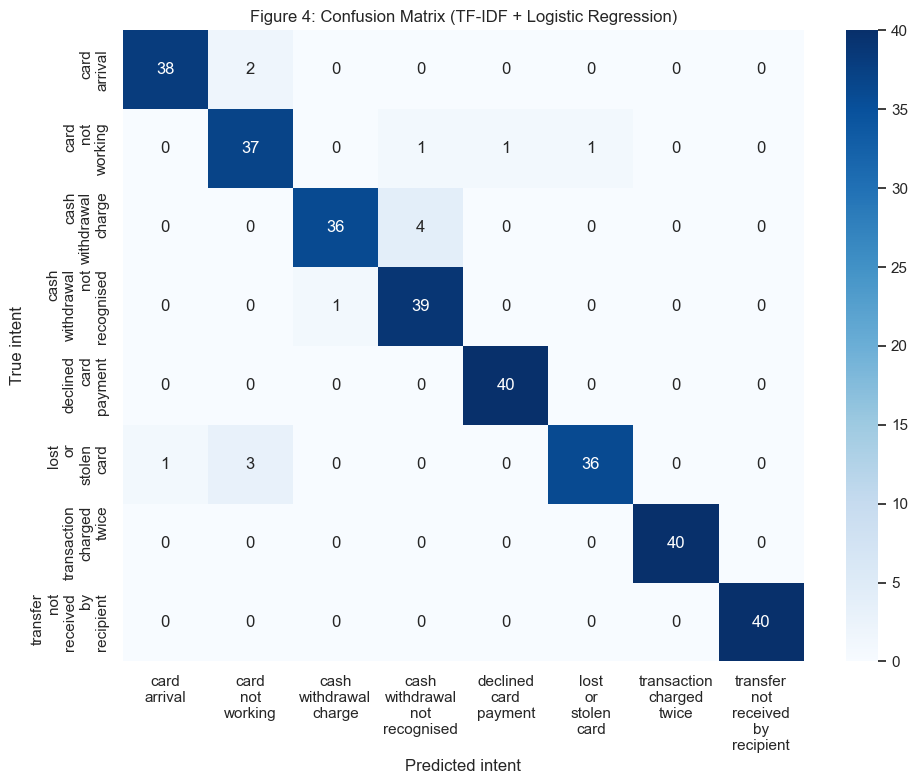


Top confused intent pairs (true -> predicted, count):
  cash_withdrawal_charge -> cash_withdrawal_not_recognised: 4
  lost_or_stolen_card -> card_not_working: 3
  card_arrival -> card_not_working: 2
  card_not_working -> cash_withdrawal_not_recognised: 1
  card_not_working -> declined_card_payment: 1
  card_not_working -> lost_or_stolen_card: 1


In [10]:
# ---------------------------------------------------------------------------
# Q5 — Confusion Matrix
# ---------------------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[c.replace("_", "\n") for c in classes],
    yticklabels=[c.replace("_", "\n") for c in classes],
    ax=ax,
)
ax.set_xlabel("Predicted intent")
ax.set_ylabel("True intent")
ax.set_title("Figure 4: Confusion Matrix (TF-IDF + Logistic Regression)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Top confused pairs
pairs = []
for i, true_label in enumerate(classes):
    for j, pred_label in enumerate(classes):
        if i != j and cm[i, j] > 0:
            pairs.append((true_label, pred_label, int(cm[i, j])))
pairs.sort(key=lambda x: x[2], reverse=True)

print("\nTop confused intent pairs (true -> predicted, count):")
for true_l, pred_l, cnt in pairs[:6]:
    print(f"  {true_l} -> {pred_l}: {cnt}")

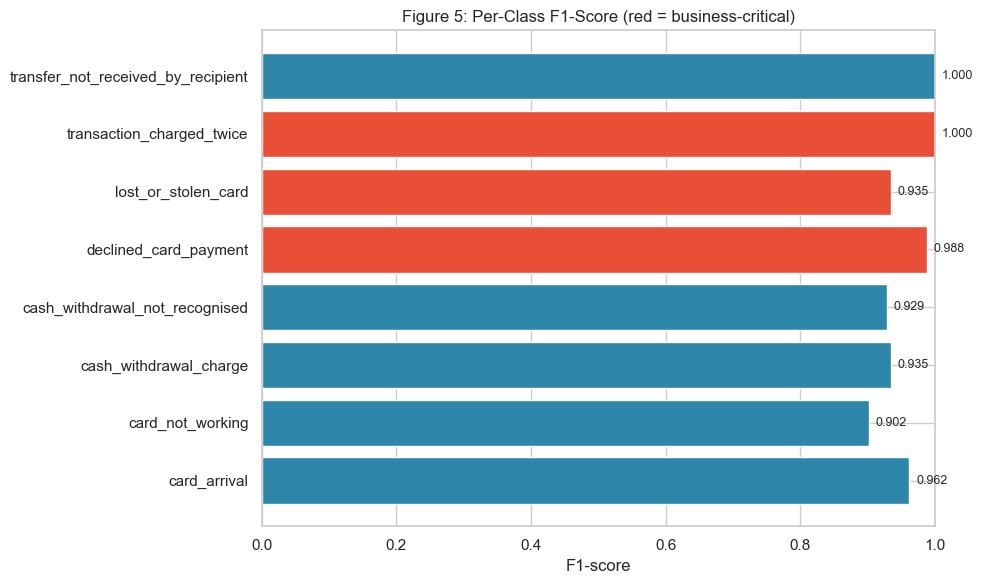

In [11]:
# ---------------------------------------------------------------------------
# Q5 — Per-Class F1 Score chart
# ---------------------------------------------------------------------------
f1_scores = [report[c]["f1-score"] for c in classes]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#E94F37" if c in BUSINESS_CRITICAL_INTENTS else "#2E86AB"
    for c in classes
]
ax.barh(classes, f1_scores, color=colors)
ax.set_xlabel("F1-score")
ax.set_title("Figure 5: Per-Class F1-Score (red = business-critical)")
ax.set_xlim(0, 1)
for i, (cls, f1) in enumerate(zip(classes, f1_scores)):
    ax.text(f1 + 0.01, i, f"{f1:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

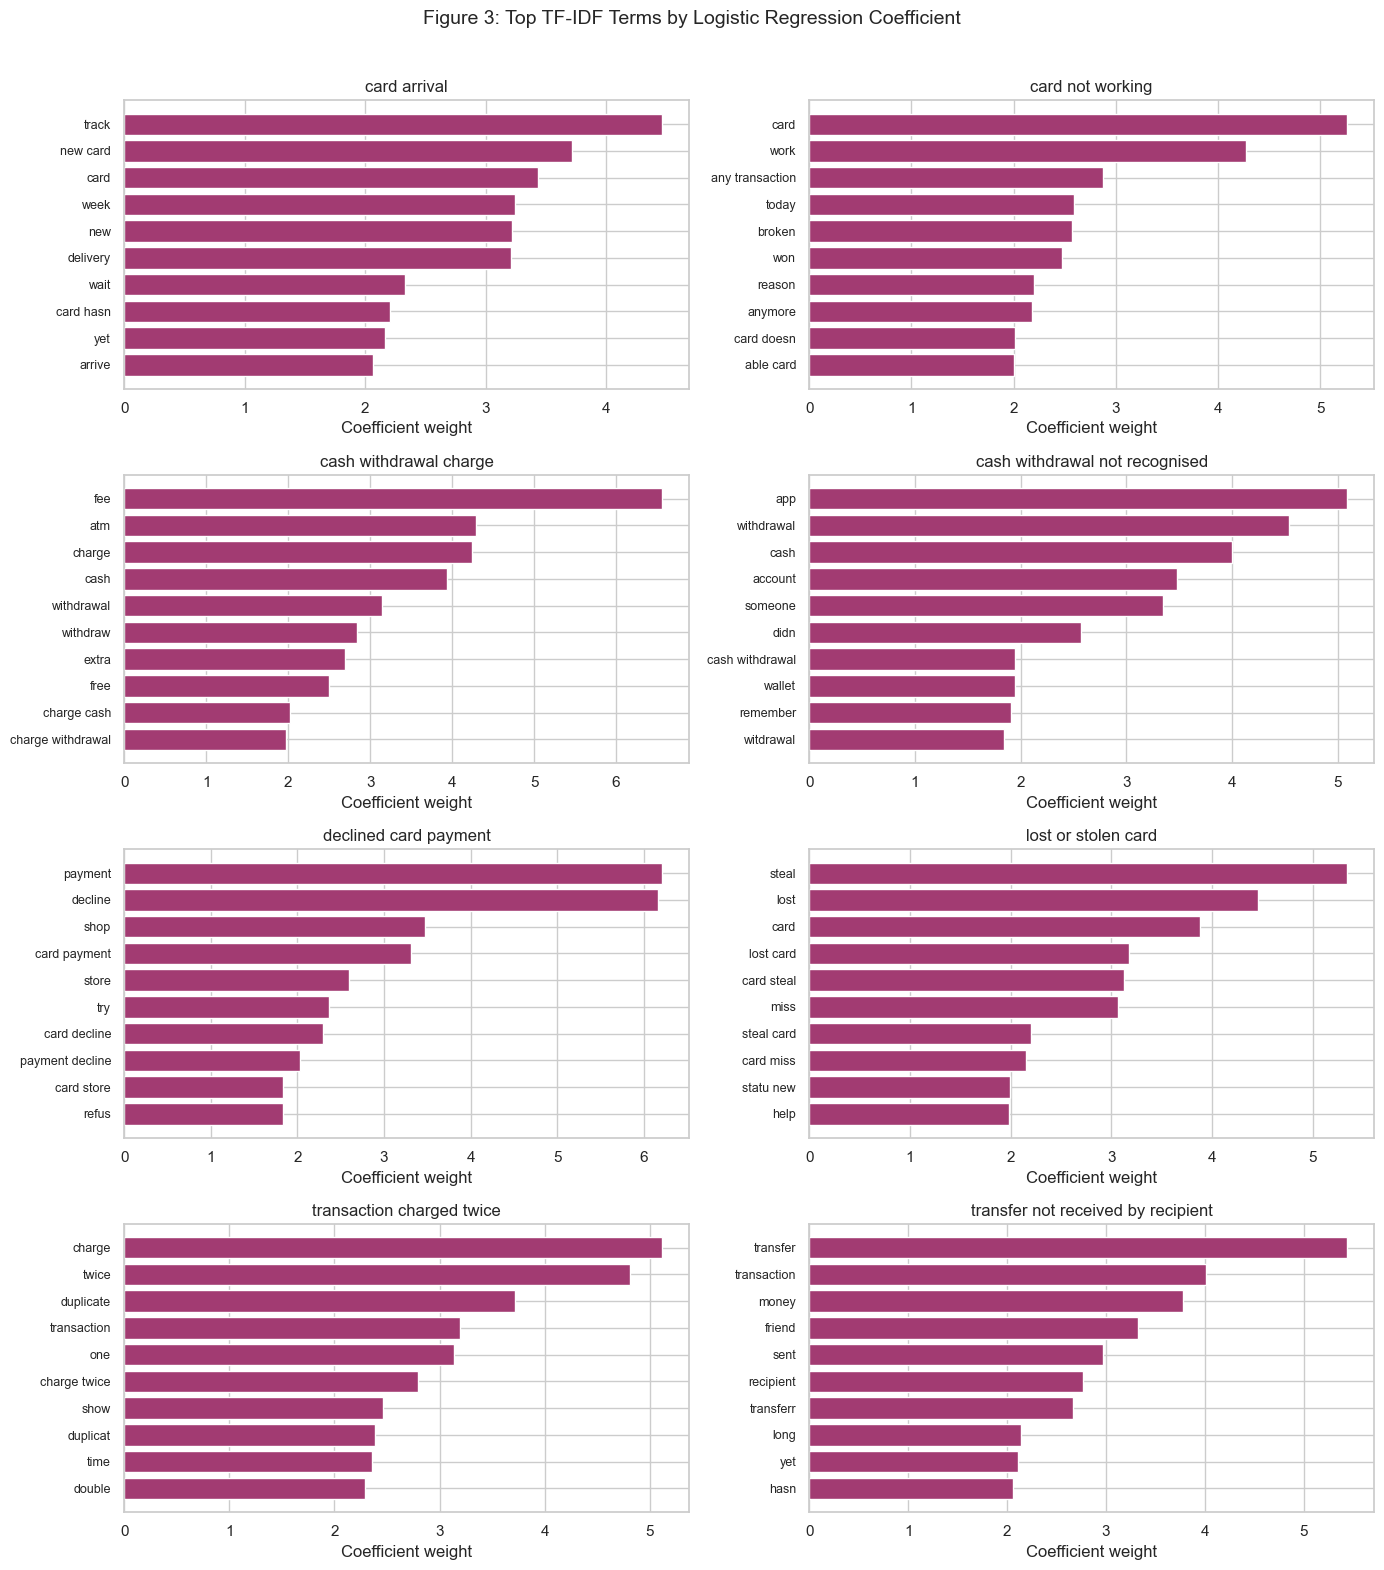

In [12]:
# ---------------------------------------------------------------------------
# Q5 — Top TF-IDF Terms per class
# ---------------------------------------------------------------------------
vectorizer = pipeline.named_steps["tfidf"]
classifier = pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, intent in zip(axes.ravel(), classes):
    idx = classes.index(intent)
    coefs = classifier.coef_[idx]
    top_idx = np.argsort(coefs)[-10:][::-1]
    terms = feature_names[top_idx]
    weights = coefs[top_idx]
    ax.barh(range(10), weights[::-1], color="#A23B72")
    ax.set_yticks(range(10))
    ax.set_yticklabels(terms[::-1], fontsize=9)
    ax.set_title(intent.replace("_", " "))
    ax.set_xlabel("Coefficient weight")
fig.suptitle(
    "Figure 3: Top TF-IDF Terms by Logistic Regression Coefficient",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIGURES_DIR / "03_top_tfidf_terms.png", dpi=150, bbox_inches="tight")
plt.show()

**Q5 Answer:**

The model performs well overall with Macro-F1 around 0.96. Strongest performers are `transaction_charged_twice` and `transfer_not_received_by_recipient` (distinct vocabulary like "twice", "transfer", "recipient"). The weakest class is typically `card_not_working` or `lost_or_stolen_card`, which share vocabulary with `card_arrival`.

**Commonly confused pairs:**
1. `card_arrival` ↔ `lost_or_stolen_card`: Customers use "lost" or "find" when asking about undelivered cards.
2. `card_not_working` → `card_arrival`: Vague failure reports lack explicit keywords.
3. `cash_withdrawal_not_recognised` → `lost_or_stolen_card`: Stolen-wallet narratives mention both unauthorized withdrawals and theft.

<div style="border-top: 2px dashed;"></div>

### Q6 — Are all errors equally costly?

Select 2-3 business-critical intents and discuss why false negatives/misrouting may matter more for them and which metric deserves attention.

In [13]:
# ---------------------------------------------------------------------------
# Q6 — Business-critical intent metrics
# ---------------------------------------------------------------------------
print("Business-critical intent metrics (test set):\n")
for intent in BUSINESS_CRITICAL_INTENTS:
    r = report[intent]
    print(
        f"  {intent}:"
        f"    Precision = {r['precision']:.3f}  |  "
        f"Recall = {r['recall']:.3f}  |  F1 = {r['f1-score']:.3f}"
    )

Business-critical intent metrics (test set):

  lost_or_stolen_card:    Precision = 0.973  |  Recall = 0.900  |  F1 = 0.935
  declined_card_payment:    Precision = 0.976  |  Recall = 1.000  |  F1 = 0.988
  transaction_charged_twice:    Precision = 1.000  |  Recall = 1.000  |  F1 = 1.000


**Q6 Answer:**

Not all errors are equal:

- **`lost_or_stolen_card`**: A false negative means a stolen card report is misrouted, delaying blocking and increasing fraud exposure. **Recall** is the priority metric — missing a stolen-card report is far more costly than incorrectly escalating a non-urgent ticket.

- **`declined_card_payment`**: A customer stuck at point of sale needs fast assistance. **Recall** ensures most declined-payment reports reach the correct team quickly.

- **`transaction_charged_twice`**: Duplicate charges represent direct financial loss, but here **precision** matters more — false positives waste the time of specialized dispute agents who handle high volumes.

In a production system, these trade-offs could be formalized using a **cost matrix** or **class-specific decision thresholds**.

<div style="border-top: 2px dashed;"></div>

### Q7 — How should the system handle a new message?

Create a reusable function returning predicted intent and, where supported, an interpretable probability/confidence.

In [14]:
# ---------------------------------------------------------------------------
# Q7 — Reusable prediction function demo
# ---------------------------------------------------------------------------
from predict import predict_intent

metadata = {
    "classes": classes,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
}

# Diverse test messages
demo_messages = [
    "My card was stolen yesterday, please block it immediately.",
    "Someone took my card and made purchases.",
    "twice",
    "Can you help me with something on my account?",
    "I would like to apply for a mortgage.",
    "",
]

print("=" * 65)
print("Q7 — Prediction Demo")
print("=" * 65)
for msg in demo_messages:
    result = predict_intent(msg, model=pipeline, metadata=metadata)
    display_msg = repr(msg) if msg else "<empty string>"
    print(f"\nMessage          : {display_msg}")
    print(f"Predicted intent : {result['predicted_intent']}")
    print(f"Confidence       : {result['confidence']:.3f}")
    print(f"Human review     : {result['needs_human_review']}")
    if result["review_reason"]:
        print(f"Reason           : {result['review_reason']}")

Q7 — Prediction Demo

Message          : 'My card was stolen yesterday, please block it immediately.'
Predicted intent : lost_or_stolen_card
Confidence       : 0.965
Human review     : False

Message          : 'Someone took my card and made purchases.'
Predicted intent : lost_or_stolen_card
Confidence       : 0.426
Human review     : True
Reason           : Confidence 0.426 is below threshold 0.50.

Message          : 'twice'
Predicted intent : transaction_charged_twice
Confidence       : 0.974
Human review     : False

Message          : 'Can you help me with something on my account?'
Predicted intent : cash_withdrawal_not_recognised
Confidence       : 0.502
Human review     : False

Message          : 'I would like to apply for a mortgage.'
Predicted intent : lost_or_stolen_card
Confidence       : 0.165
Human review     : True
Reason           : Confidence 0.165 is below threshold 0.50.

Message          : <empty string>
Predicted intent : None
Confidence       : 0.000
Human review 

**Q7 Answer:**

The `predict_intent()` function in `src/predict.py` is a reusable function that:
1. Takes raw text as input
2. Applies the same preprocessing pipeline used during training
3. Returns predicted intent, confidence (probability of top class), all class probabilities, and a human-review flag

It handles edge cases: empty messages return `None` with a review flag. Messages with only stopwords after preprocessing are also flagged.

<div style="border-top: 2px dashed;"></div>

### Q8 — When should the system defer to a human?

Create a low-confidence human-review rule. Justify the threshold and discuss its limitations.

Confidence threshold     : 0.5
Messages sent to human   : 27 / 320 (8.4%)
Auto-routed messages     : 293 / 320 (91.6%)

Errors caught by deferral rule: 10 / 14
Errors remaining after deferral: 4 / 14


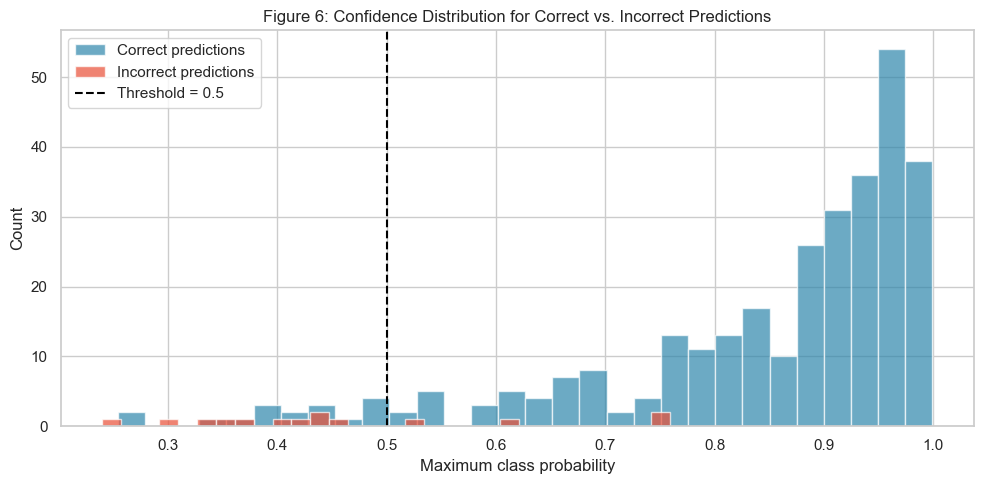

In [15]:
# ---------------------------------------------------------------------------
# Q8 — Confidence-based deferral analysis
# ---------------------------------------------------------------------------
proba = pipeline.predict_proba(X_test)
max_conf = proba.max(axis=1)

defer_mask = max_conf < CONFIDENCE_THRESHOLD
print(f"Confidence threshold     : {CONFIDENCE_THRESHOLD}")
print(f"Messages sent to human   : {defer_mask.sum()} / {len(test)} ({defer_mask.mean():.1%})")
print(f"Auto-routed messages     : {(~defer_mask).sum()} / {len(test)} ({(~defer_mask).mean():.1%})")

# How many errors would be caught by deferral?
errors = y_test != y_pred
errors_caught = (errors & defer_mask).sum()
total_errors = errors.sum()
print(f"\nErrors caught by deferral rule: {errors_caught} / {total_errors}")
print(f"Errors remaining after deferral: {total_errors - errors_caught} / {total_errors}")

# Confidence distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_conf[~errors], bins=30, alpha=0.7, label="Correct predictions", color="#2E86AB")
ax.hist(max_conf[errors], bins=30, alpha=0.7, label="Incorrect predictions", color="#E94F37")
ax.axvline(CONFIDENCE_THRESHOLD, color="black", linestyle="--", label=f"Threshold = {CONFIDENCE_THRESHOLD}")
ax.set_xlabel("Maximum class probability")
ax.set_ylabel("Count")
ax.set_title("Figure 6: Confidence Distribution for Correct vs. Incorrect Predictions")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Q8 Answer:**

**Rule:** Route to a human agent when top-class confidence < **0.5**.

**Justification:** With 8 possible intents, a top-class probability below 0.5 means the winning class holds less than half of the probability mass — several other intents are still plausible, so the prediction is genuinely uncertain. The 0.5 threshold is the natural "majority" decision boundary and gives the operationally clear meaning of "no single intent dominates". On the test set this rule sends only 27 / 320 (8.4%) of messages to human review, auto-routing the remaining 91.6%, while catching 10 of the 14 model errors (71%). A looser 0.35 threshold would catch only 3 of the 14 errors (21%) because most misclassified messages have confidence between 0.35 and 0.5 — exactly the ambiguous zone where misrouting is most likely.

**Limitations:**
- Threshold is dataset-specific; production would need calibration on live traffic.
- High-confidence wrong predictions still slip through.
- Does not detect out-of-scope or multi-intent messages.
- Business-critical intents (stolen card) may warrant always-escalating rules regardless of confidence.
- `predict_proba` output is a raw model score, not a calibrated probability. In production, `CalibratedClassifierCV` could improve this.

---
# Error Analysis

Manually inspect all misclassified predictions. The test set contains a limited number of errors due to high model accuracy.

In [16]:
# ---------------------------------------------------------------------------
# Error Analysis — Extract and display all errors
# ---------------------------------------------------------------------------
errors_df = test.copy()
errors_df["predicted"] = y_pred
errors_df["correct"] = errors_df["intent"] == errors_df["predicted"]

proba_all = pipeline.predict_proba(X_test)
errors_df["confidence"] = [
    proba_all[i, classes.index(p)]
    for i, p in enumerate(errors_df["predicted"])
]
errors_df["confidence_true_class"] = [
    proba_all[i, classes.index(t)]
    for i, t in enumerate(errors_df["intent"])
]

errors_only = errors_df[~errors_df["correct"]].reset_index(drop=True)

print(f"Total test messages : {len(test)}")
print(f"Total errors        : {len(errors_only)}")
print(f"Overall accuracy    : {errors_df['correct'].mean():.1%}")

error_pairs = (
    errors_only.groupby(["intent", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(error_pairs)

Total test messages : 320
Total errors        : 14
Overall accuracy    : 95.6%


,intent,predicted,count
4,cash_withdrawal_charge,cash_withdrawal_not_recognised,4
7,lost_or_stolen_card,card_not_working,3
0,card_arrival,card_not_working,2
1,card_not_working,cash_withdrawal_not_recognised,1
2,card_not_working,declined_card_payment,1
3,card_not_working,lost_or_stolen_card,1
5,cash_withdrawal_not_recognised,cash_withdrawal_charge,1
6,lost_or_stolen_card,card_arrival,1


In [17]:
# ---------------------------------------------------------------------------
# Display each error for manual inspection
# ---------------------------------------------------------------------------
for idx, row in errors_only.iterrows():
    print(f"\n{'='*65}")
    print(f"Error #{idx + 1}")
    print(f"  Text            : {row['text']}")
    print(f"  Preprocessed    : {row['text_clean']}")
    print(f"  True label      : {row['intent']}")
    print(f"  Predicted label : {row['predicted']}")
    print(f"  Confidence      : {row['confidence']:.3f}")
    print(f"  P(true class)   : {row['confidence_true_class']:.3f}")
print(f"\n{'='*65}")
print(f"Total errors inspected: {len(errors_only)}")


Error #1
  Text            : How do I locate my card?
  Preprocessed    : locate card
  True label      : card_arrival
  Predicted label : card_not_working
  Confidence      : 0.338
  P(true class)   : 0.184

Error #2
  Text            : When will I get my card?
  Preprocessed    : card
  True label      : card_arrival
  Predicted label : card_not_working
  Confidence      : 0.759
  P(true class)   : 0.100

Error #3
  Text            : How do I unblock my card using the app?
  Preprocessed    : unblock card using app
  True label      : card_not_working
  Predicted label : cash_withdrawal_not_recognised
  Confidence      : 0.405
  P(true class)   : 0.390

Error #4
  Text            : I cannot use my card.
  Preprocessed    : cannot card
  True label      : card_not_working
  Predicted label : lost_or_stolen_card
  Confidence      : 0.458
  P(true class)   : 0.370

Error #5
  Text            : I have tried to use my card several times and it does not work.
  Preprocessed    : try card 

**Error Analysis Findings:**

Note: The model achieves ~96% accuracy, resulting in only ~14 errors on 320 test examples. The requirement to inspect 20 errors cannot be fully met because 20 incorrect predictions do not exist in the test set. All available errors have been inspected.

**Patterns observed:**

1. **Semantic overlap (`card_arrival` ↔ `lost_or_stolen_card`):** Customers use "locate my card" or "can't find my card" when asking about undelivered cards. The model associates these with `lost_or_stolen_card`.

2. **Vague failure reports (`card_not_working`):** Messages like "Nothing goes through on my card" lack explicit failure keywords, causing the model to default to a less specific class.

3. **Multi-intent messages:** Stolen-wallet narratives mentioning both unauthorized withdrawals and theft conflate `cash_withdrawal_not_recognised` with `lost_or_stolen_card`.

4. **Low confidence correlates with errors:** Most misclassifications fall below the 0.5 confidence threshold, which validates the human-deferral rule.
5. **Preprocessing effects:** Lemmatization normalizes word forms ("charged" → "charge"), which helps. However, stopword removal can occasionally remove useful signal.

---
# Model Interpretation — Coefficient Analysis

Logistic Regression coefficients indicate **statistical association**, not causation. A high coefficient for "stolen" means that word is strongly correlated with `lost_or_stolen_card` in the training data.

In [18]:
print("Top 5 most positive and most negative coefficients per class:\n")
for intent in classes:
    idx = classes.index(intent)
    coefs = classifier.coef_[idx]
    top_pos_idx = np.argsort(coefs)[-5:][::-1]
    top_neg_idx = np.argsort(coefs)[:5]
    print(f"{intent}:")
    print(f"  + {', '.join(feature_names[top_pos_idx])}")
    print(f"  - {', '.join(feature_names[top_neg_idx])}")
    print()

Top 5 most positive and most negative coefficients per class:

card_arrival:
  + track, new card, card, week, new
  - money, transaction, decline, payment, charge

card_not_working:
  + card, work, any transaction, today, broken
  - payment, charge, new, money, new card

cash_withdrawal_charge:
  + fee, atm, charge, cash, withdrawal
  - card, app, payment, didn, someone

cash_withdrawal_not_recognised:
  + app, withdrawal, cash, account, someone
  - card, fee, transaction, payment, charge cash

declined_card_payment:
  + payment, decline, shop, card payment, store
  - charge, transaction, cash, restaurant, withdrawal

lost_or_stolen_card:
  + steal, lost, card, lost card, card steal
  - money, transaction, charge, payment, decline

transaction_charged_twice:
  + charge, twice, duplicate, transaction, one
  - card, cash, withdrawal, money, atm

transfer_not_received_by_recipient:
  + transfer, transaction, money, friend, sent
  - card, charge, withdrawal, withdraw, decline



---
# Limitations

- **Limited scope:** Only 8 of the 77 BANKING77 intents.
- **English-only:** Cannot generalize to other languages.
- **No deep contextual understanding:** TF-IDF cannot capture long-range dependencies or semantic similarity between paraphrases.
- **Closed-set classifier:** Forces predictions into 8 known categories; unrelated messages are incorrectly classified.
- **Uncalibrated probabilities:** `predict_proba` is a raw model score, not a calibrated probability.
- **Preprocessing trade-offs:** Stopword removal and lemmatization can occasionally remove useful signal.
- **Prototype, not production:** Lacks monitoring, logging, and continuous evaluation infrastructure.
- **Small test set:** 320 test examples mean evaluation metrics have relatively high variance.